In [1]:
import numpy as np
import matplotlib.pyplot as plt
import surprise
import pandas as pd

In [65]:
np.__version__

'1.24.4'

In [ ]:
data = surprise.Dataset.load_from_file("C:\_PHD\TMEs-ML\TME7\mvlenssmall\movielenssmall.csv", surprise.Reader())

In [43]:
df = pd.read_csv("C:\_PHD\TMEs-ML\TME7\mvlenssmall\movielenssmall.csv", header=None, index_col=None, sep=r"\s+", names=["user_id", "movie_id", "rating"])


In [44]:
df

,user_id,movie_id,rating
0,0,0,4.0
1,4,0,4.0
2,6,0,4.5
3,14,0,2.5
4,16,0,4.5
...,...,...,...
79604,329,2119,4.0
79605,336,2119,1.0
79606,378,2119,3.0
79607,512,2119,3.5


Histogramme des notes

<Axes: >

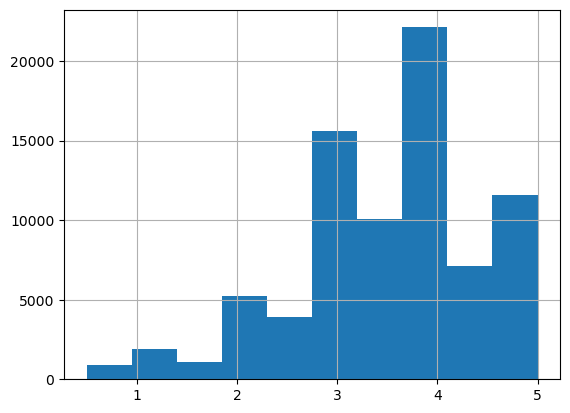

In [47]:
df.rating.hist()

Histogramme du nombre d'avis par film

In [ ]:
movie_groups = df.groupby(by="movie_id")
nb_avis_par_film = [len(group) for id, group in movie_groups]

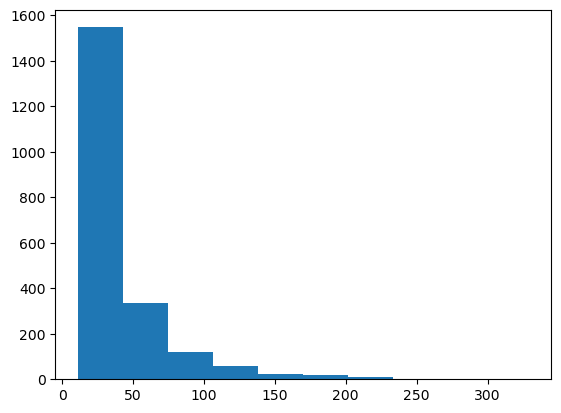

In [51]:
h = plt.hist(nb_avis_par_film)

Histogramme du nombre d'avis par utilisateur

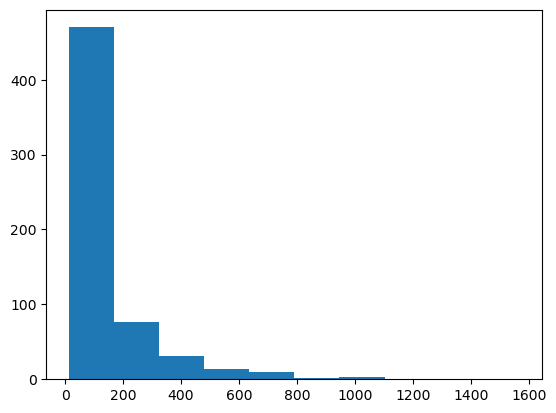

In [52]:
user_groups = df.groupby(by="user_id")
nb_avis_par_user = [len(group) for id, group in user_groups]
h = plt.hist(nb_avis_par_user)

Histogramme des notes moyennes des films

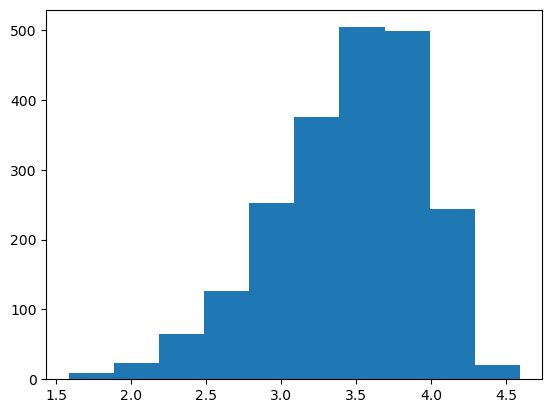

In [ ]:
notes_moyennes_films = [np.mean(group.rating) for id, group in movie_groups]
h = plt.hist(notes_moyennes_films)

notes moyennes des utilisateurs

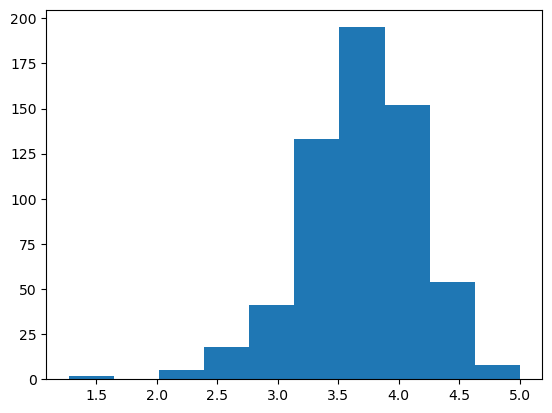

In [55]:
notes_moyennes_user = [np.mean(group.rating) for id, group in user_groups]
h = plt.hist(notes_moyennes_user)

Visualiser la matrice de distance pair à pair entre utilisateurs avec une distance euclidienne et distance cosinus

In [61]:
nb_movies = df.movie_id.max()+1
nb_users = df.user_id.max()+1
nb_movies, nb_users

(2120, 608)

In [ ]:
# Représenter chaque utilisateur par le vecteur de ses notes
# Calculer les distances pair à pair
user_movie_matrix = np.zeros((nb_users, nb_movies))
for i, row in df.iterrows():
    user_movie_matrix[int(row.user_id), int(row.movie_id)] = row.rating
    
# Plus rapide
# user_movie_df = df.pivot(index="user_id", columns="movie_id", values="rating").fillna(0)
# user_movie_matrix = user_movie_df.to_numpy()

# Ou
# user_movie_matrix = np.zeros((nb_users, nb_movies))
# user_movie_matrix[df["user_id"].to_numpy(), df["movie_id"].to_numpy()] = df["rating"].to_numpy()

In [ ]:
#np.save("user_movie_matrix.npy", user_movie_matrix)

In [ ]:
# Plus rapide
# from sklearn.metrics import pairwise_distances

# pairwise_user_eucl_distances = pairwise_distances(user_movie_matrix, metric="euclidean")
# pairwise_user_cosine_distances = pairwise_distances(user_movie_matrix, metric="cosine")

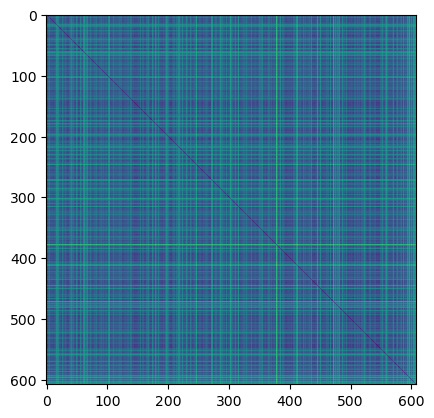

In [ ]:
pairwise_user_eucl_distances = np.array([[np.linalg.norm(a-b) for b in user_movie_matrix] for a in user_movie_matrix])
plt.imshow(pairwise_user_eucl_distances)

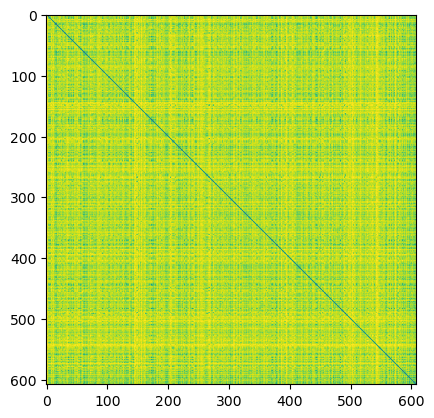

In [78]:
pairwise_user_cosine_distances = np.array([[1- (a@b)/(np.linalg.norm(a)*np.linalg.norm(b)) for b in user_movie_matrix] for a in user_movie_matrix])
plt.imshow(pairwise_user_cosine_distances)

Calculer la sparsité du jeu de données

In [90]:
#sparsity = np.sum(user_movie_matrix==0) / (user_movie_matrix.shape[0]*user_movie_matrix.shape[1])
sparsity = 1 - np.count_nonzero(user_movie_matrix) / user_movie_matrix.size
sparsity

0.938237804121152

# Partie 2

## Diviser le jeu de données en train/test

In [42]:
from surprise import Reader, Dataset
from surprise.model_selection import train_test_split
from surprise.prediction_algorithms import BaselineOnly, KNNBasic, KNNWithMeans, SVD, NMF
from surprise.accuracy import rmse, mae, fcp

In [ ]:
df = pd.read_csv("C:\_PHD\TMEs-ML\TME7\mvlenssmall\movielenssmall.csv", header=None, index_col=None, sep=r"\s+", names=["user_id", "movie_id", "rating"])
reader = Reader(rating_scale=(df.rating.min(), df.rating.max()))
data = Dataset.load_from_df(df[["user_id", "movie_id", "rating"]], reader)
trainset, testset = train_test_split(data, test_size=0.25, random_state=42)

In [ ]:
#Ou bien avec load_from_file, mais moins robuste car en passant par un dataframe
#on peut nettoyer le fichier et le formater correctement et faire des statistiques
reader = Reader(rating_scale=(1,5), sep=' ') 
data = Dataset.load_from_file("C:\_PHD\TMEs-ML\TME7\mvlenssmall\movielenssmall.csv", reader)
train, test = train_test_split(data, test_size=0.25, random_state=42)

## Tester des méthodes

In [28]:
algo = BaselineOnly()

# Train the algorithm on the trainset, and predict ratings for the testset
algo.fit(trainset)
predictions = algo.test(testset)
_ = rmse(predictions)
_ = mae(predictions)

Estimating biases using als...
RMSE: 0.8500
MAE:  0.6527


Tester à la chaîne

In [43]:
algos = {"BaselineOnly": BaselineOnly(), "KNNBasic":KNNBasic(), "KNNWithMeans":KNNWithMeans(), "SVD":SVD(), "NMF":NMF()}
results = {}
for name, algo in algos.items():
    print(f"\n---evaluating {name}---")
    algo.fit(trainset)
    predictions = algo.test(testset)
    rmse_value = rmse(predictions, verbose=False)
    mae_value = mae(predictions, verbose=False)
    fcp_value = fcp(predictions, verbose=False)
    results[name] = {"rmse": np.round(rmse_value, 3), "mae": np.round(mae_value, 3), "fcp": np.round(fcp_value, 3)}


---evaluating BaselineOnly---
Estimating biases using als...

---evaluating KNNBasic---
Computing the msd similarity matrix...
Done computing similarity matrix.

---evaluating KNNWithMeans---
Computing the msd similarity matrix...
Done computing similarity matrix.

---evaluating SVD---

---evaluating NMF---


Comparer

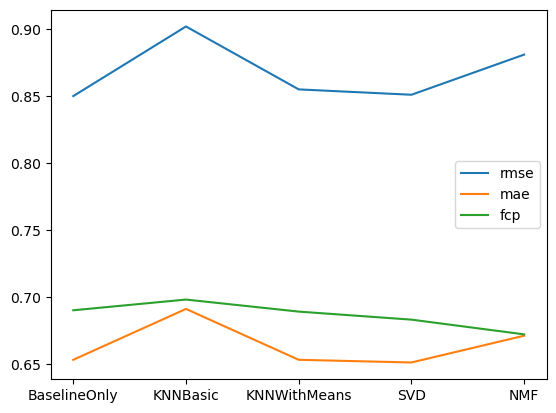

In [ ]:
rmse_values = [result["rmse"] for name, result in results.items()]
plt.plot(results.keys(), rmse_values, label="rmse")
mae_values = [result["mae"] for name, result in results.items()]
plt.plot(results.keys(), mae_values, label="mae")
fcp_values = [result["fcp"] for name, result in results.items()]
plt.plot(results.keys(), fcp_values, label="fcp")
_ = plt.legend()

### Analyse des méthodes par factorisation de matrices 

In [50]:
from sklearn.manifold import TSNE

In [ ]:
algo = SVD()
_ = algo.fit(trainset)
predictions = algo.test(testset)

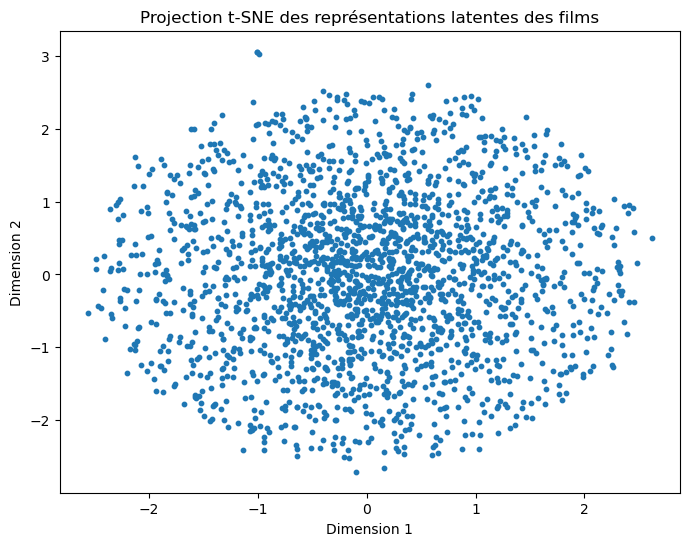

In [57]:
# Représentations latentes des films
item_embeddings = algo.qi   # shape = (nb_items_train, n_factors)

# t-SNE vers 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=100)
item_2d = tsne.fit_transform(item_embeddings)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(item_2d[:, 0], item_2d[:, 1], s=10)
plt.title("Projection t-SNE des représentations latentes des films")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

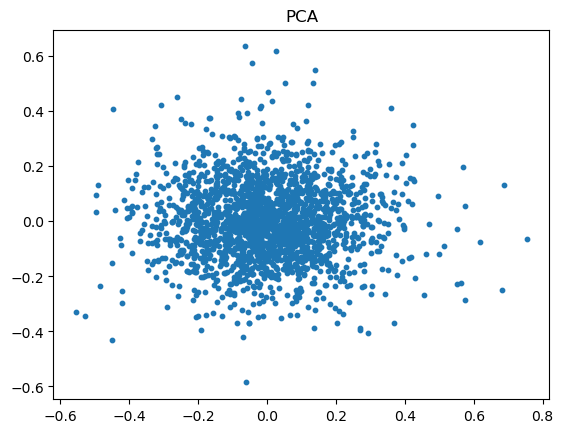

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
proj = pca.fit_transform(item_embeddings)

plt.scatter(proj[:,0], proj[:,1], s=10)
plt.title("PCA")
plt.show()

NMF

In [58]:
algo = NMF()
_ = algo.fit(trainset)
predictions = algo.test(testset)

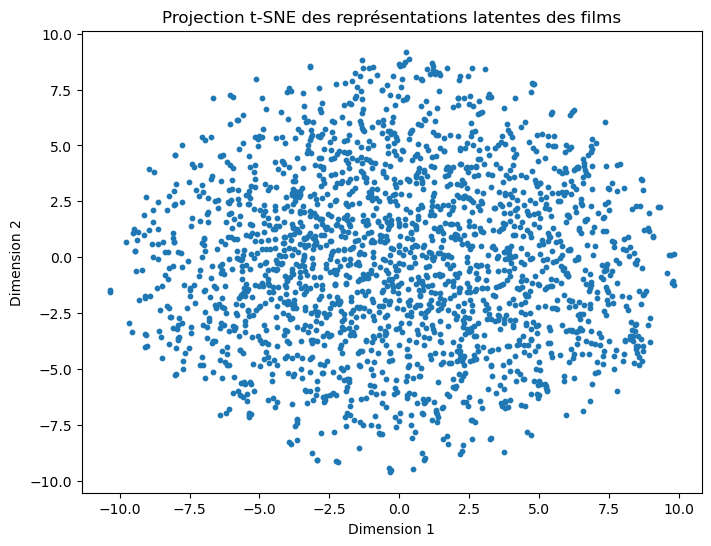

In [59]:
# Représentations latentes des films
item_embeddings = algo.qi   # shape = (nb_items_train, n_factors)

# t-SNE vers 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=100)
item_2d = tsne.fit_transform(item_embeddings)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(item_2d[:, 0], item_2d[:, 1], s=10)
plt.title("Projection t-SNE des représentations latentes des films")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

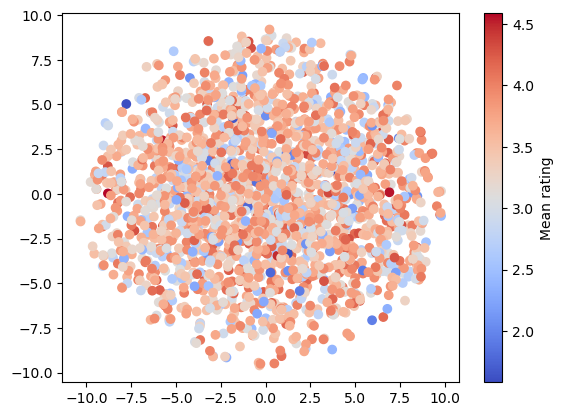

In [62]:
movie_mean = df.groupby("movie_id")["rating"].mean()

colors = [movie_mean.get(mid, 0) for mid in range(nb_movies)]

plt.scatter(item_2d[:,0], item_2d[:,1], c=colors, cmap="coolwarm")
plt.colorbar(label="Mean rating")